In [1]:
import pandas as pd

df = pd.read_csv(r'F:\Dataset\MURA-v1.1\train_image_paths.csv')
print(df.head())

  MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/image1.png
0  MURA-v1.1/train/XR_SHOULDER/patient00001/study...                 
1  MURA-v1.1/train/XR_SHOULDER/patient00001/study...                 
2  MURA-v1.1/train/XR_SHOULDER/patient00002/study...                 
3  MURA-v1.1/train/XR_SHOULDER/patient00002/study...                 
4  MURA-v1.1/train/XR_SHOULDER/patient00002/study...                 


In [2]:
import pandas as pd

df_train = pd.read_csv(r'F:\Dataset\MURA-v1.1\train_image_paths.csv')
print(df_train.columns)

Index(['MURA-v1.1/train/XR_SHOULDER/patient00001/study1_positive/image1.png'], dtype='object')


In [3]:
import pandas as pd
import os

BASE_PATH = r'F:\Dataset\MURA-v1.1'

df_train = pd.read_csv(rf'{BASE_PATH}\train_image_paths.csv', header=None)
df_train.columns = ['image_path']
df_train['path'] = df_train['image_path'].apply(lambda x: os.path.join(BASE_PATH, x.replace('MURA-v1.1/', '')))
df_train['label'] = df_train['image_path'].apply(lambda x: 1 if 'positive' in x else 0)
df_train['body_part'] = df_train['image_path'].apply(lambda x: x.split('/')[2])

df_test = pd.read_csv(rf'{BASE_PATH}\valid_image_paths.csv', header=None)
df_test.columns = ['image_path']
df_test['path'] = df_test['image_path'].apply(lambda x: os.path.join(BASE_PATH, x.replace('MURA-v1.1/', '')))
df_test['label'] = df_test['image_path'].apply(lambda x: 1 if 'positive' in x else 0)
df_test['body_part'] = df_test['image_path'].apply(lambda x: x.split('/')[2])

print(df_train.head())
print(df_test.head())

                                          image_path  \
0  MURA-v1.1/train/XR_SHOULDER/patient00001/study...   
1  MURA-v1.1/train/XR_SHOULDER/patient00001/study...   
2  MURA-v1.1/train/XR_SHOULDER/patient00001/study...   
3  MURA-v1.1/train/XR_SHOULDER/patient00002/study...   
4  MURA-v1.1/train/XR_SHOULDER/patient00002/study...   

                                                path  label    body_part  
0  F:\Dataset\MURA-v1.1\train/XR_SHOULDER/patient...      1  XR_SHOULDER  
1  F:\Dataset\MURA-v1.1\train/XR_SHOULDER/patient...      1  XR_SHOULDER  
2  F:\Dataset\MURA-v1.1\train/XR_SHOULDER/patient...      1  XR_SHOULDER  
3  F:\Dataset\MURA-v1.1\train/XR_SHOULDER/patient...      1  XR_SHOULDER  
4  F:\Dataset\MURA-v1.1\train/XR_SHOULDER/patient...      1  XR_SHOULDER  
                                          image_path  \
0  MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...   
1  MURA-v1.1/valid/XR_WRIST/patient11185/study1_p...   
2  MURA-v1.1/valid/XR_WRIST/patient11185/stud

In [4]:
from sklearn.model_selection import train_test_split

# Create a stratification key combining body part + label
df_train['stratify_group'] = df_train['body_part'] + "_" + df_train['label'].astype(str)

# Stratified 80/20 split
df_train_final, df_val_final = train_test_split(
    df_train,
    test_size=0.2,
    random_state=42,
    stratify=df_train['stratify_group']
)


In [5]:
# Distribution and Sanity Check

print("Training set:")
print(df_train_final['body_part'].value_counts(normalize=True))

print("\nValidation set:")
print(df_val_final['body_part'].value_counts(normalize=True))

Training set:
body_part
XR_WRIST       0.264960
XR_SHOULDER    0.227637
XR_HAND        0.150581
XR_FINGER      0.138695
XR_ELBOW       0.133974
XR_FOREARM     0.049582
XR_HUMERUS     0.034572
Name: proportion, dtype: float64

Validation set:
body_part
XR_WRIST       0.264874
XR_SHOULDER    0.227656
XR_HAND        0.150638
XR_FINGER      0.138821
XR_ELBOW       0.133931
XR_FOREARM     0.049579
XR_HUMERUS     0.034501
Name: proportion, dtype: float64


In [6]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch
import numpy as np

class MuraDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row["path"]
        label = row["label"]

        image = Image.open(image_path).convert("L")
        if self.transform:
            image = self.transform(image)

        return image, label 
print("Dataset defined!")

Dataset defined!


In [7]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize before augmenting
    transforms.RandomHorizontalFlip(p=0.5),   # Minor flip — common in medical images
    transforms.RandomRotation(degrees=10),    # Small angle preserves structure
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Slight lighting changes
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # For grayscale

])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # For grayscale

])

In [8]:
from torch.utils.data import DataLoader

# Train
train_dataset = MuraDataset(df_train_final, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)  
# Validation
val_dataset = MuraDataset(df_val_final, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

# Test
test_dataset = MuraDataset(df_test, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)  

print(f"Train: {len(train_loader)} batches ")
print(f"Val: {len(val_loader)} batches ")
print(f"Test: {len(test_loader)} batches ")

Train: 921 batches 
Val: 231 batches 
Test: 100 batches 


In [9]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti


In [10]:
!pip install timm

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import efficientnet_v2_s
import timm

class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = self.fc(self.avg_pool(x).view(x.size(0), -1))
        max = self.fc(self.max_pool(x).view(x.size(0), -1))
        return x * self.sigmoid(avg + max).view(x.size(0), x.size(1), 1, 1)


class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        max, _ = torch.max(x, dim=1, keepdim=True)
        return x * self.sigmoid(self.conv(torch.cat([avg, max], dim=1)))


class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):
        return self.spatial_attention(self.channel_attention(x))


class DualFracNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        # EfficientNetV2-S (224x224)
        efficient = efficientnet_v2_s(weights="DEFAULT" if pretrained else None)
        efficient.features[0][0] = nn.Conv2d(1, 24, kernel_size=3, stride=2, padding=1, bias=False)
        self.efficient_backbone = efficient.features
        self.efficient_pool = nn.AdaptiveAvgPool2d(1)

        # SwinV1-Tiny (224x224) 
        self.swin = timm.create_model('swin_tiny_patch4_window7_224', pretrained=pretrained)
        self.swin.patch_embed.proj = nn.Conv2d(1, 96, kernel_size=4, stride=4)

        # Feature projection
        self.efficient_proj = nn.Linear(1280, 1024)
        self.swin_proj = nn.Linear(768, 1024)

        # Feature fusion
        self.fusion = nn.Sequential(
            nn.Linear(2048, 2048),
            nn.LayerNorm(2048),
            nn.GELU(),
            nn.Dropout(0.3)
        )

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        # EfficientNetV2 branch (224x224)
        e = self.efficient_pool(self.efficient_backbone(x)).flatten(1)
        e = self.efficient_proj(e)  # (B, 1024)

        # SwinV1 branch (224x224) 
        s = self.swin.forward_features(x)
        if s.dim() == 3:
            s = s.mean(dim=1)
        elif s.dim() == 4:
            s = s.mean(dim=[1, 2])
        s = self.swin_proj(s)  # (B, 1024)

        # Concat + Fusion
        combined = torch.cat([e, s], dim=1)  # (B, 2048)
        combined = self.fusion(combined)

        return self.classifier(combined)


model = DualFracNet(pretrained=True).to(device)
print(f"DualFracNet ready! Parameters: {sum(p.numel() for p in model.parameters()):,}")

DualFracNet ready! Parameters: 55,943,940


In [12]:
import torch
import torch.nn as nn

fracture_loss_fn = nn.CrossEntropyLoss()


model = DualFracNet(pretrained=True).to(device)

# Optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

print("Model ready! ")

Model ready! 


In [13]:
def train_one_epoch(model, loader, optimizer, fracture_loss_fn):
    model.train()
    total_loss, correct_frac = 0, 0

    for images, labels in loader:  
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        out_fracture = model(images)  

        loss = fracture_loss_fn(out_fracture, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct_frac += (out_fracture.argmax(1) == labels).sum().item()

    n = len(loader.dataset)
    return total_loss / len(loader), correct_frac / n


def validate(model, loader, fracture_loss_fn):
    model.eval()
    total_loss, correct_frac = 0, 0

    with torch.no_grad():
        for images, labels in loader: 
            images = images.to(device)
            labels = labels.to(device)

            out_fracture = model(images)  

            loss = fracture_loss_fn(out_fracture, labels)

            total_loss += loss.item()
            correct_frac += (out_fracture.argmax(1) == labels).sum().item()

    n = len(loader.dataset)
    return total_loss / len(loader), correct_frac / n

print("Functions defined!")

Functions defined!


In [14]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

print(next(model.parameters()).device)

True
NVIDIA GeForce RTX 4060 Ti
cuda:0


In [15]:
import torch
from sklearn.metrics import roc_curve, auc

best_val_loss = float('inf')
early_stop_counter = 0
early_stop_patience = 5
epochs = 30

# CURVE STORAGE
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(epochs):
    train_loss, train_fracture_acc = train_one_epoch(
        model, train_loader, optimizer, fracture_loss_fn
    )
    val_loss, val_fracture_acc = validate(
        model, val_loader, fracture_loss_fn
    )
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_fracture_acc)
    val_accs.append(val_fracture_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Frac Acc: {train_fracture_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Frac Acc: {val_fracture_acc:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), r'F:\Dataset\dualfracnet_mura.pt')  
        print(f"Best model saved! Val Loss: {val_loss:.4f}")
    else:
        early_stop_counter += 1
        print(f"Early stop patience: {early_stop_counter}/{early_stop_patience}")
        if early_stop_counter >= early_stop_patience:
            print("Early stopping triggered.")
            break

# Best model load
model.load_state_dict(torch.load(r'F:\Dataset\dualfracnet_mura.pt'))  
model.eval()

# ROC CURVE
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        out_fracture = model(images)
        probs = torch.softmax(out_fracture, dim=1)[:, 1]
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
print(f"AUC Score: {roc_auc:.4f} ")

Epoch 1/30 | Train Loss: 0.5718, Frac Acc: 0.7047 | Val Loss: 0.5054, Frac Acc: 0.7704
Best model saved! Val Loss: 0.5054
Epoch 2/30 | Train Loss: 0.5030, Frac Acc: 0.7684 | Val Loss: 0.4774, Frac Acc: 0.7779
Best model saved! Val Loss: 0.4774
Epoch 3/30 | Train Loss: 0.4822, Frac Acc: 0.7809 | Val Loss: 0.5067, Frac Acc: 0.7710
Early stop patience: 1/5
Epoch 4/30 | Train Loss: 0.4831, Frac Acc: 0.7830 | Val Loss: 0.4725, Frac Acc: 0.7827
Best model saved! Val Loss: 0.4725
Epoch 5/30 | Train Loss: 0.4792, Frac Acc: 0.7861 | Val Loss: 0.4598, Frac Acc: 0.7865
Best model saved! Val Loss: 0.4598
Epoch 6/30 | Train Loss: 0.4713, Frac Acc: 0.7904 | Val Loss: 0.4518, Frac Acc: 0.8026
Best model saved! Val Loss: 0.4518
Epoch 7/30 | Train Loss: 0.4673, Frac Acc: 0.7919 | Val Loss: 0.5022, Frac Acc: 0.7609
Early stop patience: 1/5
Epoch 8/30 | Train Loss: 0.4618, Frac Acc: 0.7950 | Val Loss: 0.4378, Frac Acc: 0.8071
Best model saved! Val Loss: 0.4378
Epoch 9/30 | Train Loss: 0.4576, Frac Acc: 0

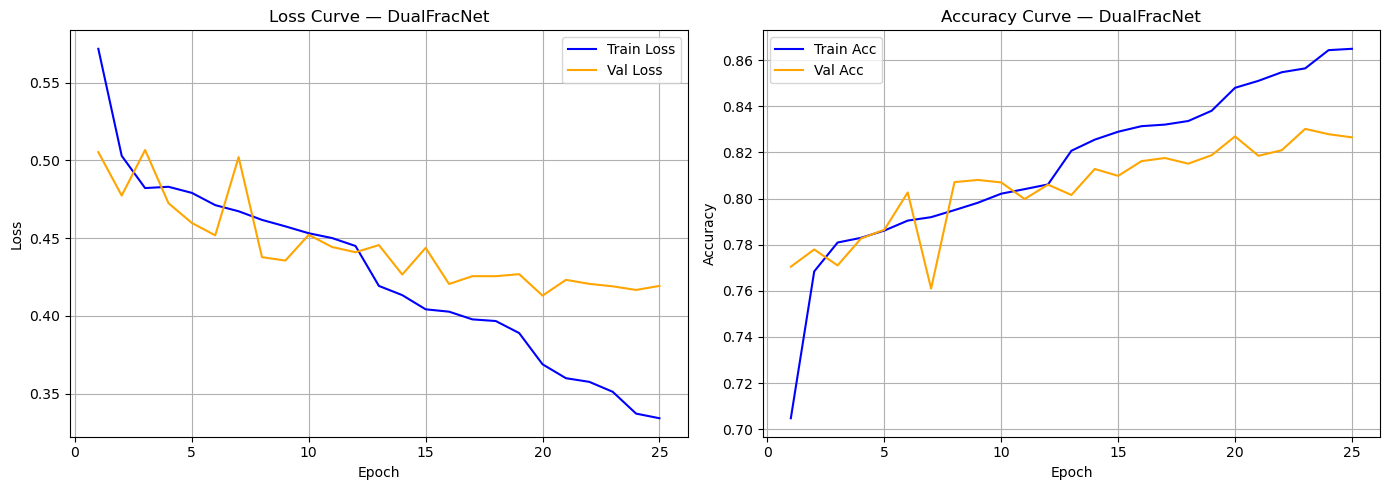

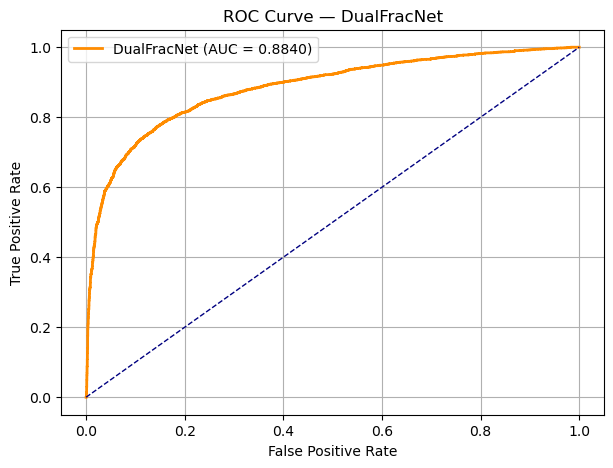

Curves saved! 


In [16]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curve
axes[0].plot(epochs_range, train_losses, label='Train Loss', color='blue')
axes[0].plot(epochs_range, val_losses, label='Val Loss', color='orange')
axes[0].set_title('Loss Curve — DualFracNet')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy Curve
axes[1].plot(epochs_range, train_accs, label='Train Acc', color='blue')
axes[1].plot(epochs_range, val_accs, label='Val Acc', color='orange')
axes[1].set_title('Accuracy Curve — DualFracNet')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(r'F:\Dataset\dualfracnet_curves.png', dpi=300)  
plt.show()

# ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'DualFracNet (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — DualFracNet')
plt.legend()
plt.grid(True)
plt.savefig(r'F:\Dataset\dualfracnet_roc.png', dpi=300)  
plt.show()

print("Curves saved! ")

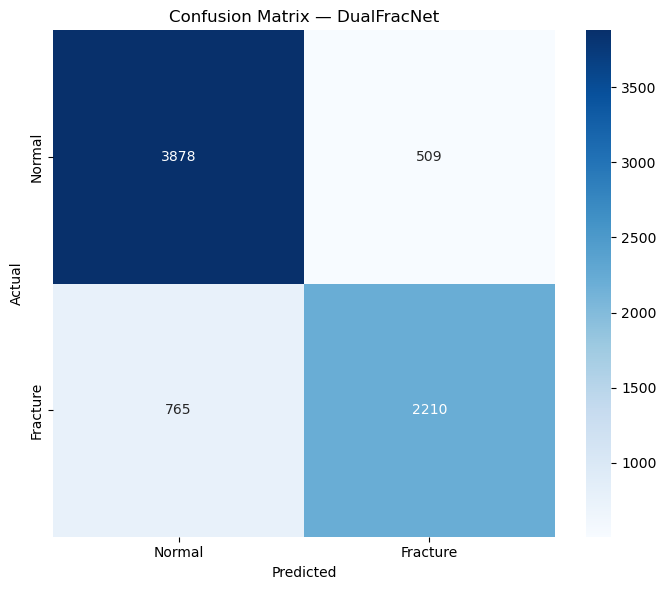

              precision    recall  f1-score   support

      Normal       0.84      0.88      0.86      4387
    Fracture       0.81      0.74      0.78      2975

    accuracy                           0.83      7362
   macro avg       0.82      0.81      0.82      7362
weighted avg       0.83      0.83      0.83      7362



In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
model.eval()
all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)
        out = model(images)
        preds = torch.argmax(out, dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
class_names = ['Normal', 'Fracture']

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix — DualFracNet')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(r'F:\Dataset\dualfracnet_confusion_matrix.png', dpi=300) 
plt.show()

# Classification Report
print(classification_report(all_labels, all_preds, target_names=class_names))

In [24]:
import sys
print(sys.executable)

C:\Users\Robotics Lab\anaconda3\envs\stt_env\python.exe


In [26]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "show", "opencv-python"])

CompletedProcess(args=['C:\\Users\\Robotics Lab\\anaconda3\\envs\\stt_env\\python.exe', '-m', 'pip', 'show', 'opencv-python'], returncode=1)

In [28]:
import sys
!"{sys.executable}" -m pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)


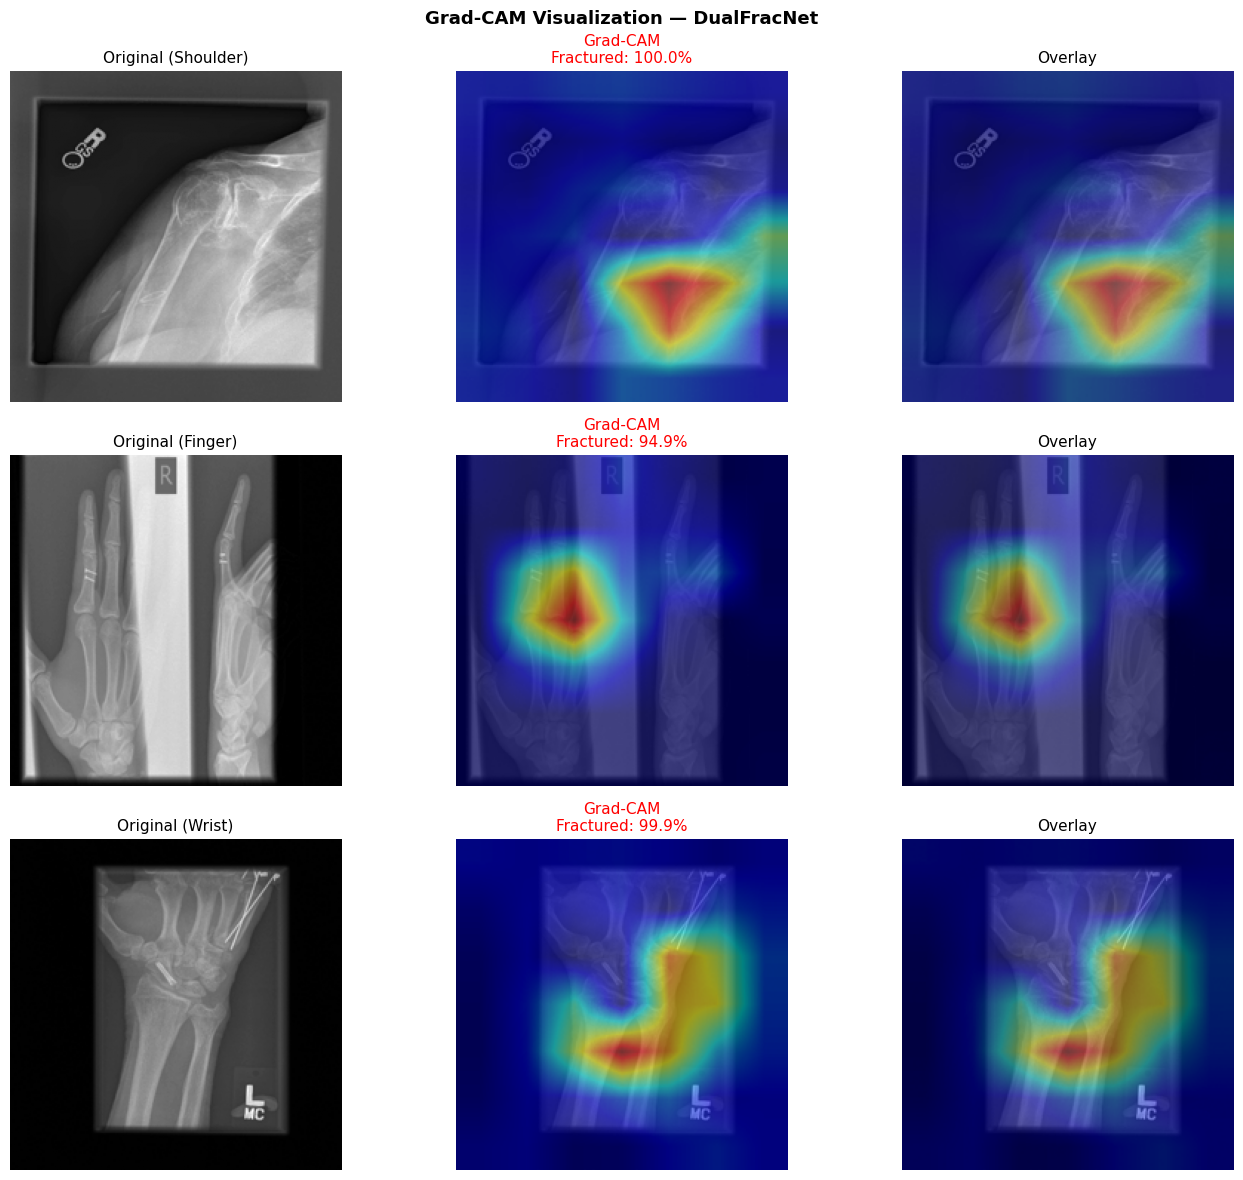

Saved! 


In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torchvision.transforms as transforms

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=1):
        self.model.eval()
        output = self.model(input_tensor)
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

target_layer = model.efficient_backbone[-1]
gradcam = GradCAM(model, target_layer)

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

selected_paths = [
    r'F:\Dataset\MURA-v1.1\valid\XR_SHOULDER\patient11300\study2_positive\image3.png',
    r'F:\Dataset\MURA-v1.1\valid\XR_FINGER\patient11916\study1_positive\image2.png',
    r'F:\Dataset\MURA-v1.1\valid\XR_WRIST\patient11243\study1_positive\image3.png'
]
confidences = [100.0, 94.9, 99.9]
body_parts = ['Shoulder', 'Finger', 'Wrist']

fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, (sample_path, confidence, body_part) in enumerate(zip(selected_paths, confidences, body_parts)):
    image = Image.open(sample_path).convert('L')
    input_tensor = transform(image).unsqueeze(0).to(device)

    cam = gradcam.generate(input_tensor, class_idx=1)
    cam_resized = cv2.resize(cam, (224, 224))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    orig = np.array(image.resize((224, 224)))
    orig_rgb = np.stack([orig] * 3, axis=-1)

    overlay = (0.6 * orig_rgb / 255 + 0.4 * heatmap / 255)
    overlay = np.clip(overlay, 0, 1)
    overlay = (overlay * 255).astype(np.uint8)

    gradcam_on_xray = (0.5 * orig_rgb + 0.5 * heatmap).astype(np.uint8)

    axes[i][0].imshow(orig, cmap='gray')
    axes[i][0].set_title(f'Original ({body_part})', fontsize=11)
    axes[i][0].axis('off')

    axes[i][1].imshow(gradcam_on_xray)
    axes[i][1].set_title(f'Grad-CAM\nFractured: {confidence:.1f}%', color='red', fontsize=11)
    axes[i][1].axis('off')

    axes[i][2].imshow(overlay)
    axes[i][2].set_title(f'Overlay', fontsize=11)
    axes[i][2].axis('off')

plt.suptitle('Grad-CAM Visualization — DualFracNet', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'F:\Dataset\dualfracnet_gradcam.png', dpi=300, bbox_inches='tight')  
plt.show()
print("Saved! ")

Features shape: (3197, 512)


C:\Users\Robotics Lab\anaconda3\envs\stt_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


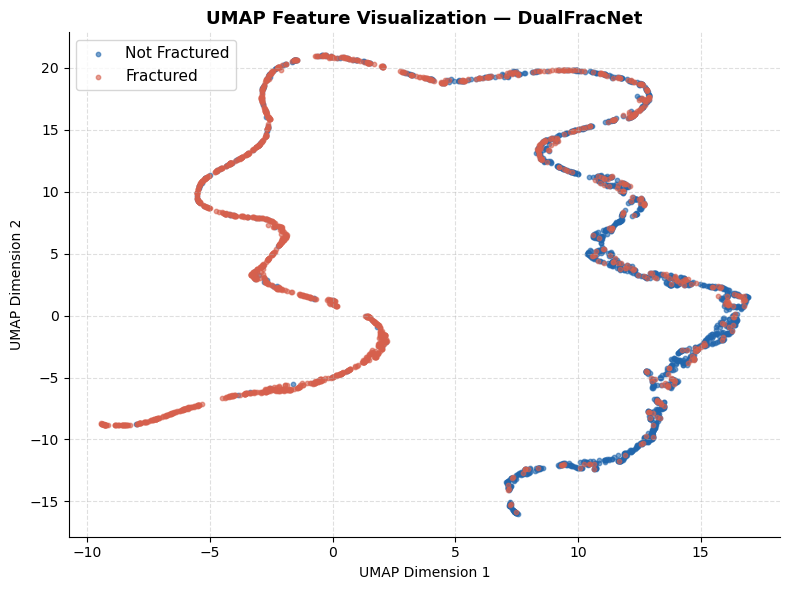

UMAP saved! 


In [41]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP

model.eval()
feature_hook = []
labels_list = []

def hook_fn(module, input, output):
    feature_hook.append(output.detach().cpu())

hook = model.classifier[0].register_forward_hook(hook_fn)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _ = model(images)
        labels_list.extend(labels.numpy())

hook.remove()

all_features = torch.cat(feature_hook, dim=0).squeeze().numpy()
all_labels = np.array(labels_list)
print(f"Features shape: {all_features.shape}")

reducer = UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(all_features)

fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: '#2166AC', 1: '#D6604D'}
label_names = {0: 'Not Fractured', 1: 'Fractured'}

for label in [0, 1]:
    mask = all_labels == label
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        c=colors[label],
        label=label_names[label],
        alpha=0.6,
        s=10
    )

ax.set_title('UMAP Feature Visualization — DualFracNet', fontweight='bold', fontsize=13)
ax.set_xlabel('UMAP Dimension 1')
ax.set_ylabel('UMAP Dimension 2')
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(r'F:\Dataset\dualfracnet_umap.png', dpi=300, bbox_inches='tight')  
plt.show()
print("UMAP saved! ")

In [42]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [43]:
import os
from glob import glob

BASE2 = r'F:\Dataset\MultiBone\Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification'

fractured_paths = glob(os.path.join(BASE2, 'test', 'fractured', '*'))
not_fractured_paths = glob(os.path.join(BASE2, 'test', 'not fractured', '*'))

print(f"Fractured images: {len(fractured_paths)}")
print(f"Not Fractured images: {len(not_fractured_paths)}")

Fractured images: 238
Not Fractured images: 268


In [44]:
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as transforms

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

class CustomXrayDataset(Dataset):
    def __init__(self, image_paths, label, transform=None):
        self.image_paths = image_paths
        self.label = label
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)
        return image, self.label

print("CustomXrayDataset defined! ")

CustomXrayDataset defined! 


In [45]:
from torch.utils.data import DataLoader, ConcatDataset

fractured_ds = CustomXrayDataset(fractured_paths, label=1, transform=test_transform)
notfractured_ds = CustomXrayDataset(not_fractured_paths, label=0, transform=test_transform)

combined_ds = ConcatDataset([fractured_ds, notfractured_ds])
combined_loader = DataLoader(combined_ds, batch_size=32, shuffle=False, num_workers=0)  

print(f"Total images: {len(combined_ds)}")

Total images: 506


In [46]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in combined_loader:  
        images = images.to(device)
        labels = labels.to(device)

        out_fracture = model(images) 
        preds = out_fracture.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Predictions done!")

Predictions done!


In [47]:
from sklearn.metrics import classification_report, confusion_matrix

print("Custom X-Ray Evaluation:")
print(classification_report(all_labels, all_preds, target_names=["Not Fractured", "Fractured"]))
print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Custom X-Ray Evaluation:
               precision    recall  f1-score   support

Not Fractured       0.66      0.83      0.74       268
    Fractured       0.74      0.53      0.61       238

     accuracy                           0.69       506
    macro avg       0.70      0.68      0.68       506
 weighted avg       0.70      0.69      0.68       506

Confusion Matrix:
[[223  45]
 [113 125]]
